In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/4
    print("準備完了！このまま下のセルを実行できます。")

# 第4章 単層ネットワーク: 回帰 (Single-layer Networks: Regression)
## 4.2 決定理論 (Decision Theory)

### 本節の目的と概要
本ノートブックでは、Christopher M. Bishop & Hugh Bishop による『*Deep Learning: Foundations and Concepts*』(2024年刊) の **Chapter 4: Single-layer Networks: Regression** のうち、**Section 4.2: Decision Theory** を体系的かつ厳密に解説・実装・検証します。

前節 4.1 では、学習データから条件付き予測分布 $p(t|\mathbf{x})$ を学習する**推論 (Inference)** を扱いました。しかし現実の応用では、単に不確実性を表現する確率分布を得るだけでなく、具体的な行動を起こすために**特定の値 $f(\mathbf{x})$ を1つ選択・決定 (Decision)** しなければなりません。
本節では以下の重要トピックを数理的・実験的に網羅します：

1. **推論段階と決定段階の分離 (Inference and Decision Stages)**: 誤差関数 (訓練時) と損失関数 (決定時) の役割の本質的相違
2. **期待損失の最小化 (Minimizing Expected Loss)**: 任意の損失関数 $L(t, f(\mathbf{x}))$ に対する期待損失 $\mathbb{E}[L]$ の定式化 (式 4.34)
3. **二乗損失と最適回帰関数 (Squared Loss & Regression Function)**: 変分法 (Calculus of variations) による条件付き平均 $f^\star(\mathbf{x}) = \mathbb{E}[t|\mathbf{x}]$ の導出 (式 4.35 - 4.38, **Figure 4.5**)
4. **期待二乗損失の直交分解 (Loss Decomposition)**: モデル誤差項と不可避ノイズ (Irreducible noise) への分解 (式 4.39)
5. **ミンコフスキー損失 (Minkowski / $L_q$ Loss)**: $q=2$ (平均), $q=1$ (中央値), $q \to 0$ (最頻値) と外れ値への頑健性 (**Figure 4.6**, 式 4.40)
6. **多峰性分布における二乗損失の破綻 (Multimodal Distributions & Failure of Squared Loss)**: 逆問題における条件付き平均の限界と混合密度ネットワークへの発展的展望

In [1]:
import os
import sys
import numpy as np
import scipy.linalg as la
import scipy.stats as stats
import matplotlib.pyplot as plt
from IPython.display import Image, display

# プロジェクトルートをパスに追加
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.plot_utils import setup_style
from common.decision_theory import (
    minkowski_loss,
    expected_squared_loss_decomposition,
    optimal_minkowski_point_prediction,
    plot_figure_4_5_regression_function,
    plot_figure_4_6_minkowski_loss
)

setup_style()
os.makedirs('result', exist_ok=True)
os.makedirs('../result', exist_ok=True)
print("環境セットアップ完了: common.decision_theory を読み込みました。")

環境セットアップ完了: common.decision_theory を読み込みました。


---
## 1. 推論段階と決定段階 (Inference vs Decision Stages)

機械学習における回帰タスクは、本質的に以下の2つの独立した段階に分解されます：

1. **推論段階 (Inference stage)**:
   訓練データ $\mathcal{D}$ を用いて、新しい入力 $\mathbf{x}$ に対する目標値 $t$ の条件付き予測確率分布 $p(t|\mathbf{x})$ を求める。
   $$
   p(t|\mathbf{x}, \mathbf{w}_{\mathrm{ML}}, \sigma_{\mathrm{ML}}^2) = \mathcal{N}(t \mid y(\mathbf{x}, \mathbf{w}_{\mathrm{ML}}), \sigma_{\mathrm{ML}}^2) \tag{4.33}
   $$
2. **決定段階 (Decision stage)**:
   得られた予測分布 $p(t|\mathbf{x})$ と、予測誤差に伴うコスト・ペナルティを表す**損失関数 (loss function)** $L(t, f(\mathbf{x}))$ を用いて、最適な単一の予測値 $f(\mathbf{x})$ を決定する。

### 誤差関数 (Error function) と損失関数 (Loss function) の相違
- **誤差関数 (Error function)**:
  モデルの未知パラメータ $\mathbf{w}$ を訓練データから最尤推定・学習する際に最小化する目的関数（例：二乗和誤差 $E_D(\mathbf{w})$）。
- **損失関数 (Loss function)**:
  すでに得られた予測分布のもとで、個々の決定 $f(\mathbf{x})$ が真の目標値 $t$ と乖離した際に被る不利益を定量化する関数。

---
## 2. 期待損失と最適回帰関数 (Expected Loss & Figure 4.5)

真の目標値 $t$ は未知であるため、損失関数そのものではなく、入力 $\mathbf{x}$ と目標値 $t$ の同時分布 $p(\mathbf{x}, t)$ で重み付けした**期待損失 (Expected Loss)** を最小化します：
$$
\mathbb{E}[L] = \iint L(t, f(\mathbf{x})) p(\mathbf{x}, t) \, \mathrm{d}\mathbf{x} \mathrm{d}t \tag{4.34}
$$
回帰問題で最も頻繁に用いられる損失は**二乗損失 (squared loss)** $L(t, f(\mathbf{x})) = \{f(\mathbf{x}) - t\}^2$ です：
$$
\mathbb{E}[L] = \iint \{f(\mathbf{x}) - t\}^2 p(\mathbf{x}, t) \, \mathrm{d}\mathbf{x} \mathrm{d}t \tag{4.35}
$$

### 変分法による最適解の導出
任意の関数形を取りうる完全に柔軟な $f(\mathbf{x})$ を仮定し、変分微分 (calculus of variations) を 0 と置きます：
$$
\frac{\delta \mathbb{E}[L]}{\delta f(\mathbf{x})} = 2 \int \{f(\mathbf{x}) - t\} p(\mathbf{x}, t) \, \mathrm{d}t = 0 \tag{4.36}
$$
確率の加法定理・乗法定理 $p(\mathbf{x}, t) = p(t|\mathbf{x})p(\mathbf{x})$ を適用して $f(\mathbf{x})$ について解くと：
$$
f^\star(\mathbf{x}) = \frac{1}{p(\mathbf{x})}\int t p(\mathbf{x}, t) \, \mathrm{d}t = \int t p(t|\mathbf{x}) \, \mathrm{d}t = \mathbb{E}_t[t \mid \mathbf{x}] \tag{4.37}
$$
すなわち、**期待二乗損失を最小化する最適な予測関数 $f^\star(\mathbf{x})$ は、入力 $\mathbf{x}$ が与えられたときの目標値 $t$ の条件付き期待値 (条件付き平均)** に他なりません。
この関数は**回帰関数 (regression function)** と呼ばれます (Figure 4.5)。

ガウスノイズモデル $p(t|\mathbf{x}) = \mathcal{N}(t|y(\mathbf{x}, \mathbf{w}), \sigma^2)$ の場合、条件付き平均はモデル関数そのものと一致します：
$$
\mathbb{E}[t \mid \mathbf{x}] = y(\mathbf{x}, \mathbf{w}) \tag{4.38}
$$

Figure 4.5 saved to: result/fig4_5_regression_function.png
Figure 4.5 saved to: ../result/fig4_5_regression_function.png


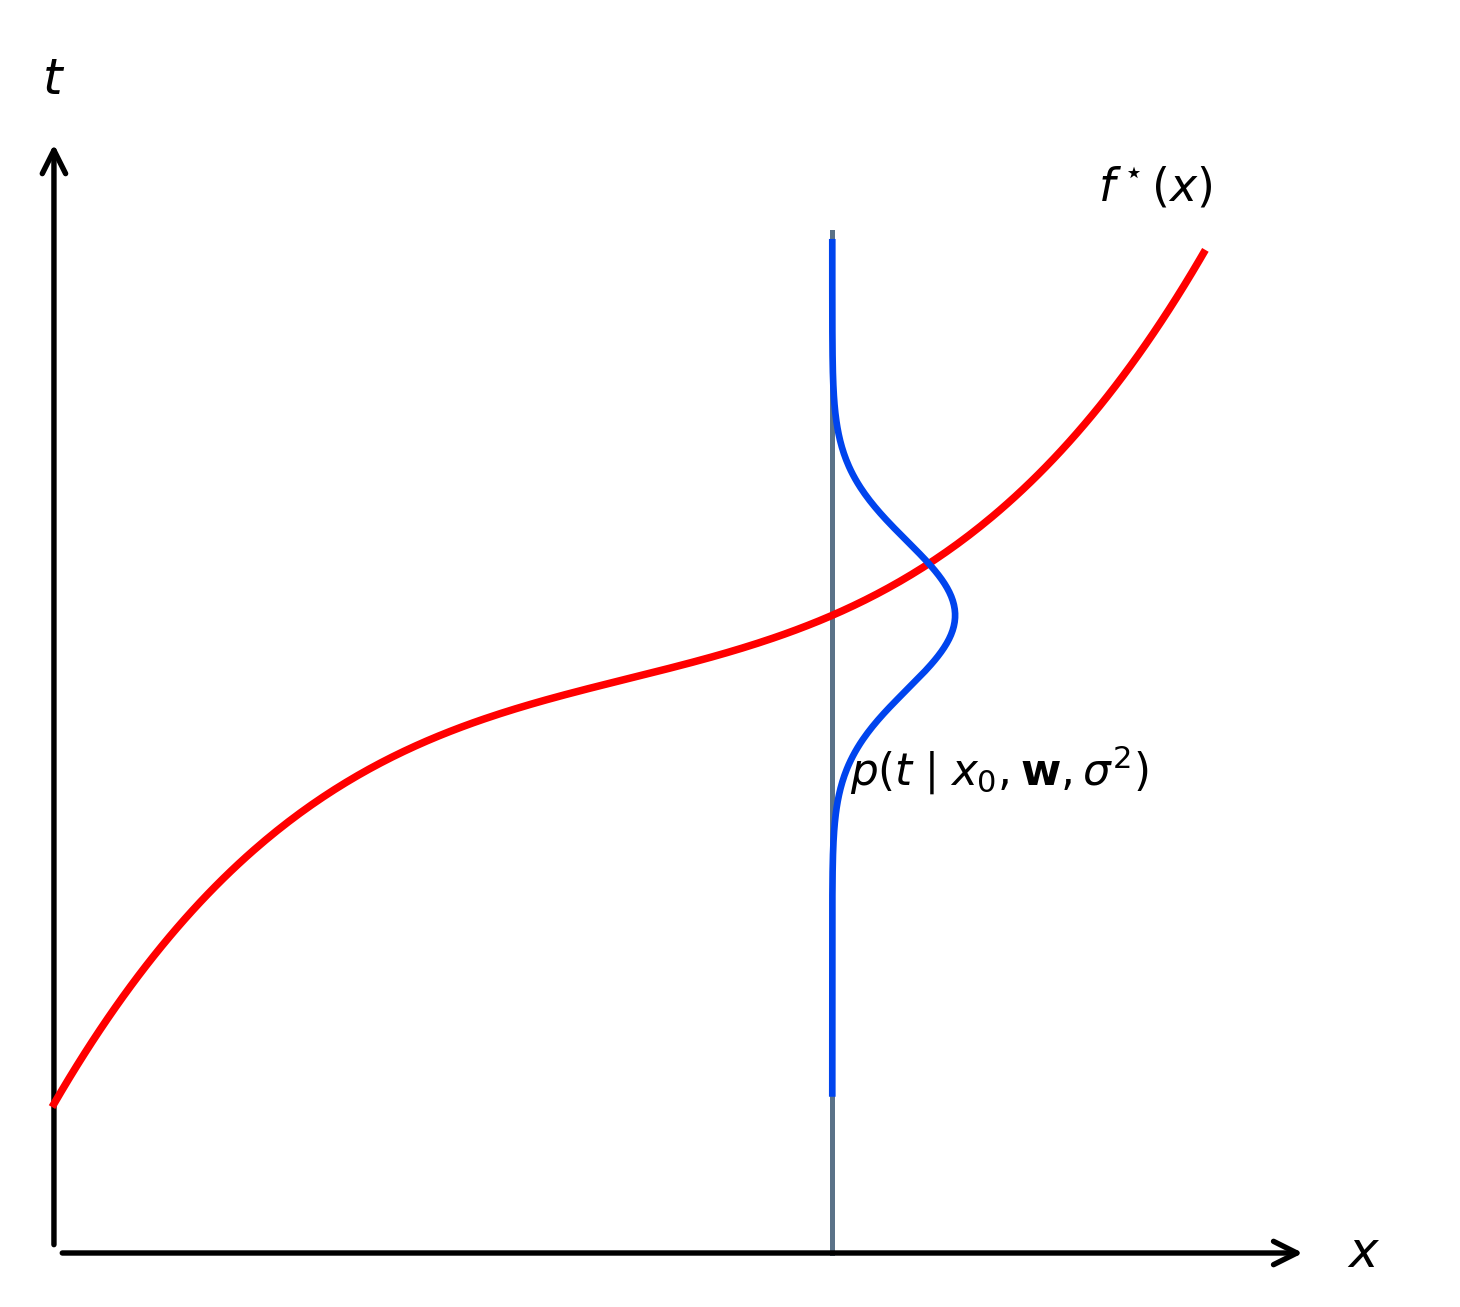

Figure 4.5: 最適回帰関数 f*(x) = E[t|x] と条件付き密度断面図を忠実に再現・保存しました。


In [2]:
# Figure 4.5: 最適回帰関数 f*(x) と条件付き分布 p(t|x0, w, sigma^2) の幾何学的プロット
fig4_5, ax4_5 = plot_figure_4_5_regression_function(
    save_paths=['result/fig4_5_regression_function.png', '../result/fig4_5_regression_function.png']
)
plt.show()
print("Figure 4.5: 最適回帰関数 f*(x) = E[t|x] と条件付き密度断面図を忠実に再現・保存しました。")

---
## 3. 期待二乗損失の直交分解 (Loss Decomposition)

最適解が条件付き期待値 $\mathbb{E}[t|\mathbf{x}]$ であることを用いると、損失関数を展開して本質的な洞察を得ることができます。
$$
\{f(\mathbf{x}) - t\}^2 = \{f(\mathbf{x}) - \mathbb{E}[t|\mathbf{x}] + \mathbb{E}[t|\mathbf{x}] - t\}^2
$$
これを2乗展開すると：
$$
\{f(\mathbf{x}) - t\}^2 = \{f(\mathbf{x}) - \mathbb{E}[t|\mathbf{x}]\}^2 + 2\{f(\mathbf{x}) - \mathbb{E}[t|\mathbf{x}]\}\{\mathbb{E}[t|\mathbf{x}] - t\} + \{\mathbb{E}[t|\mathbf{x}] - t\}^2
$$
これを式 (4.35) に代入して $t$ について積分すると、交差項 (第2項) は次のように**恒等的に 0** となります：
$$
\int \{\mathbb{E}[t|\mathbf{x}] - t\} p(t|\mathbf{x}) \, \mathrm{d}t = \mathbb{E}[t|\mathbf{x}] - \mathbb{E}[t|\mathbf{x}] = 0
$$
したがって、期待二乗損失は以下の**2つの独立な項の和**へと完全に分解されます：
$$
\mathbb{E}[L] = \int \{f(\mathbf{x}) - \mathbb{E}[t|\mathbf{x}]\}^2 p(\mathbf{x}) \, \mathrm{d}\mathbf{x} + \int \mathrm{var}[t|\mathbf{x}] p(\mathbf{x}) \, \mathrm{d}\mathbf{x} \tag{4.39}
$$

### 2つの項の物理的解釈
1. **第1項 (モデル決定誤差 / Model Error)**:
   予測関数 $f(\mathbf{x})$ と真の回帰関数 $\mathbb{E}[t|\mathbf{x}]$ の乖離の重み付き二乗平均。非負であり、$f(\mathbf{x}) = \mathbb{E}[t|\mathbf{x}]$ としたときに正確に 0 となります。
2. **第2項 (不可避ノイズ / Irreducible Noise)**:
   目標変数 $t$ の条件付き分散 $\mathrm{var}[t|\mathbf{x}]$ を入力空間全体で平均したもの。これは予測器 $f(\mathbf{x})$ に一切依存しないデータ固有の固有分散であり、**いかに優れたモデルを用いてもこれ以下にはできない期待損失の下限値**を表します。

In [3]:
# 式 (4.39) の数値的完全検証
# 真のモデル: E[t|x] = 1.5*x^2 - 0.5, var[t|x] = 0.04 (一定ノイズ)
# p(x) = Uniform(-1, 1), 密度 0.5
cond_mean = lambda x: 1.5 * (x ** 2) - 0.5
cond_var = lambda x: np.full_like(x, 0.04)
p_x = lambda x: np.full_like(x, 0.5)

# 1. 最適予測器 f*(x) = E[t|x] の場合:
f_opt = lambda x: cond_mean(x)
decomp_opt = expected_squared_loss_decomposition(f_opt, cond_mean, cond_var, p_x, x_range=(-1.0, 1.0))

print("=== 最適予測器 f*(x) ===")
print(f"  モデル決定誤差 (Model Error)   : {decomp_opt['model_error']:.8e} (理論値: 0.0)")
print(f"  不可避ノイズ (Irreducible Noise): {decomp_opt['irreducible_noise']:.6f} (理論値: 0.04)")
print(f"  総期待損失 E[L]                : {decomp_opt['expected_loss']:.6f}")

assert np.isclose(decomp_opt['model_error'], 0.0, atol=1e-8)
assert np.isclose(decomp_opt['irreducible_noise'], 0.04, atol=1e-6)

# 2. バイアスを持った不完全な予測器 f(x) = E[t|x] + 0.3 の場合:
bias_delta = 0.3
f_sub = lambda x: cond_mean(x) + bias_delta
decomp_sub = expected_squared_loss_decomposition(f_sub, cond_mean, cond_var, p_x, x_range=(-1.0, 1.0))

print()
print("=== 不完全な予測器 f(x) = E[t|x] + 0.3 ===")
print(f"  モデル決定誤差 (Model Error)   : {decomp_sub['model_error']:.6f} (理論値: {bias_delta**2:.6f})")
print(f"  不可避ノイズ (Irreducible Noise): {decomp_sub['irreducible_noise']:.6f} (理論値: 0.04)")
print(f"  総期待損失 E[L]                : {decomp_sub['expected_loss']:.6f} (理論値: {0.09 + 0.04:.6f})")

assert np.isclose(decomp_sub['model_error'], bias_delta ** 2, atol=1e-6)
assert np.isclose(decomp_sub['expected_loss'], bias_delta ** 2 + 0.04, atol=1e-6)
print()
print("Assertion Passed: 期待損失の直交分解 E[L] = Model Error + Irreducible Noise が厳密に確認されました。")

=== 最適予測器 f*(x) ===
  モデル決定誤差 (Model Error)   : 0.00000000e+00 (理論値: 0.0)
  不可避ノイズ (Irreducible Noise): 0.040000 (理論値: 0.04)
  総期待損失 E[L]                : 0.040000

=== 不完全な予測器 f(x) = E[t|x] + 0.3 ===
  モデル決定誤差 (Model Error)   : 0.090000 (理論値: 0.090000)
  不可避ノイズ (Irreducible Noise): 0.040000 (理論値: 0.04)
  総期待損失 E[L]                : 0.130000 (理論値: 0.130000)

Assertion Passed: 期待損失の直交分解 E[L] = Model Error + Irreducible Noise が厳密に確認されました。


---
## 4. ミンコフスキー損失 (Minkowski / $L_q$ Loss & Figure 4.6)

二乗損失は外れ値 (outliers) に対してペナルティが誤差の2乗で急増するため、外れ値に過度に引っ張られる脆弱性があります。二乗損失を一般化した基準として、**ミンコフスキー損失 (Minkowski loss)** があります：
$$
\mathbb{E}[L_q] = \iint |f(\mathbf{x}) - t|^q p(\mathbf{x}, t) \, \mathrm{d}\mathbf{x} \mathrm{d}t \tag{4.40}
$$
$q$ の値に応じて、期待損失を最小化する最適予測器の性質が劇的に変化します：

- **$q = 2$ (二乗損失 / $L_2$ Loss)**:
  最適予測は**条件付き平均 (Conditional Mean)** $\mathbb{E}[t|\mathbf{x}]$。
- **$q = 1$ (絶対値損失 / $L_1$ Loss / MAE)**:
  最適予測は**条件付き中央値 (Conditional Median)** $\mathrm{median}(t|\mathbf{x})$。外れ値に対してロバスト。
- **$q \to 0$ ($L_0$ 型損失)**:
  最適予測は**条件付き最頻値 (Conditional Mode)** $\mathrm{mode}(t|\mathbf{x})$（最大確率密度を与える点）。

Figure 4.6 は、$q = 0.3, 1, 2, 10$ における誤差 $f - t$ に対する損失関数値 $|f - t|^q$ の形状の違いを示しています。

Figure 4.6 saved to: result/fig4_6_minkowski_loss.png


Figure 4.6 saved to: ../result/fig4_6_minkowski_loss.png


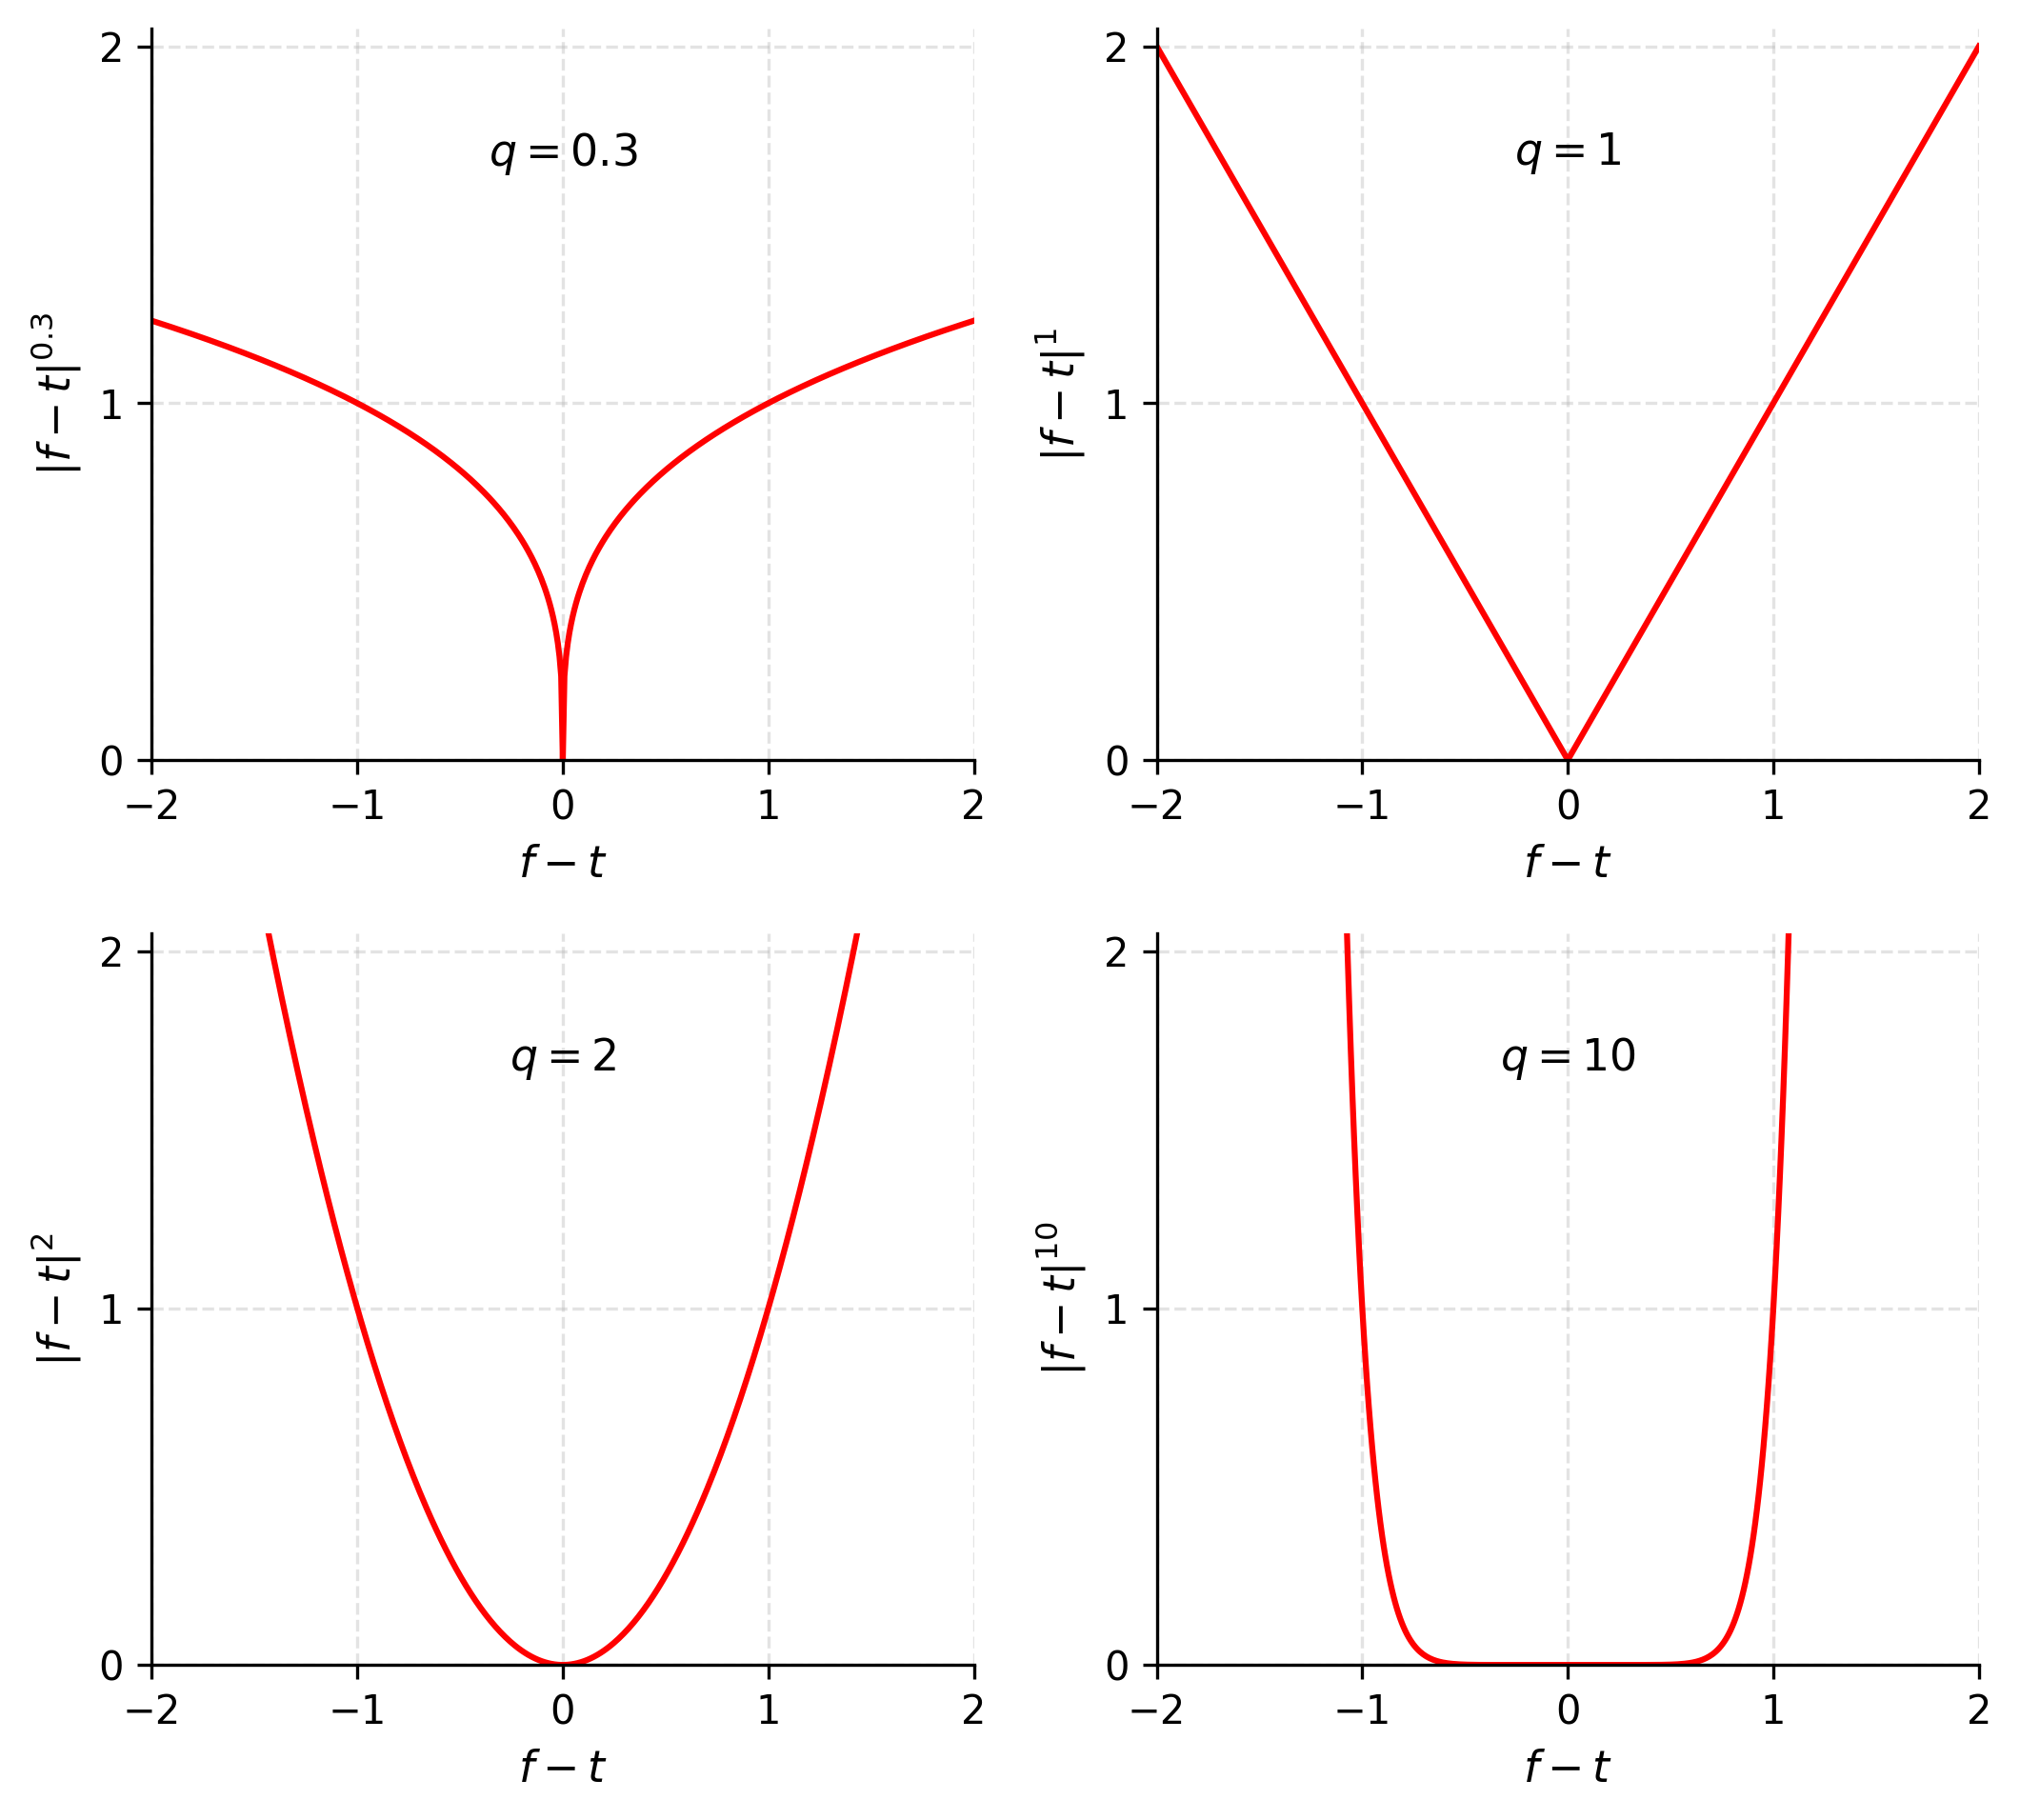

Figure 4.6: ミンコフスキー損失 L_q (q=0.3, 1, 2, 10) の2x2パネル図を完全再現・保存しました。


In [4]:
# Figure 4.6: 様々な q におけるミンコフスキー損失 L_q = |f - t|^q のプロット
fig4_6, axes4_6 = plot_figure_4_6_minkowski_loss(
    save_paths=['result/fig4_6_minkowski_loss.png', '../result/fig4_6_minkowski_loss.png']
)
plt.show()
print("Figure 4.6: ミンコフスキー損失 L_q (q=0.3, 1, 2, 10) の2x2パネル図を完全再現・保存しました。")

非対称分布における最適予測値:
  q = 2.0 (平均値 Mean)   : 1.3236 (理論値: 1.3248)
  q = 1.0 (中央値 Median) : 1.0014 (理論値: 1.0000)
  q = 0.1 (最頻値 Mode)   : 0.7828 (理論値: 0.5698)
Assertion Passed: q=2 で平均、q=1 で中央値、q->0 で最頻値に一致する理論が数値的に実証されました。


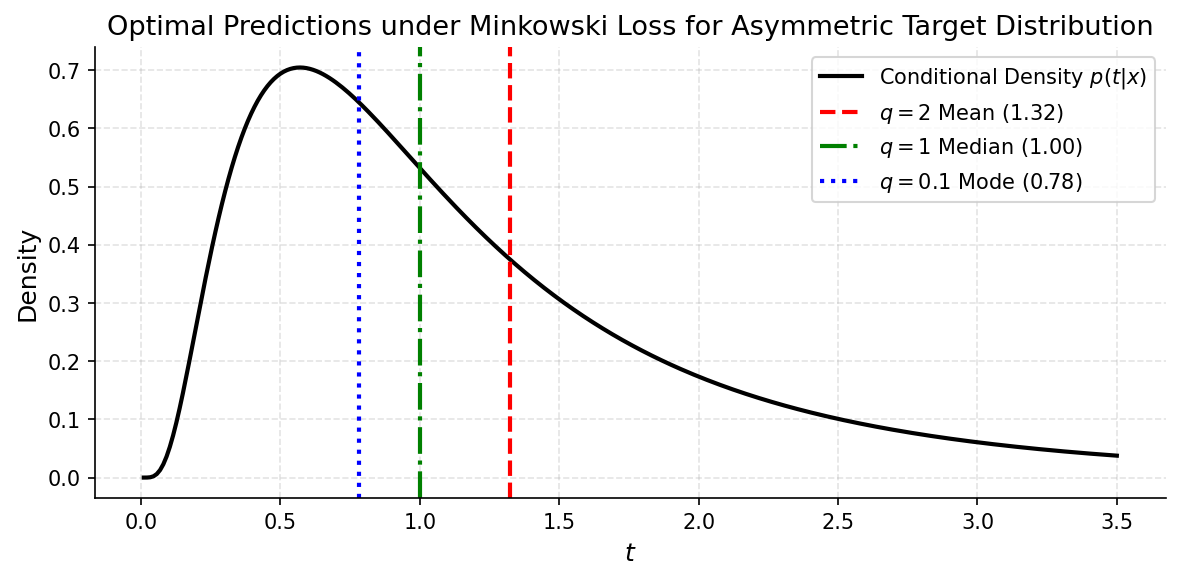

In [5]:
# 非対称 (歪んだ) 条件付き分布における q による最適予測値の違いの検証
# 対数正規分布 Log-Normal(mu=0, sigma=0.75):
# 理論値:
# Mode   = exp(mu - sigma^2)   = exp(-0.5625) ~ 0.5698
# Median = exp(mu)             = 1.0000
# Mean   = exp(mu + sigma^2/2) = exp(0.28125) ~ 1.3248

np.random.seed(42)
N_mc = 30000
samples_asym = np.random.lognormal(mean=0.0, sigma=0.75, size=N_mc)

pred_mean = optimal_minkowski_point_prediction(samples_asym, q=2.0)
pred_median = optimal_minkowski_point_prediction(samples_asym, q=1.0)
pred_mode_approx = optimal_minkowski_point_prediction(samples_asym, q=0.1)

print("非対称分布における最適予測値:")
print(f"  q = 2.0 (平均値 Mean)   : {pred_mean:.4f} (理論値: 1.3248)")
print(f"  q = 1.0 (中央値 Median) : {pred_median:.4f} (理論値: 1.0000)")
print(f"  q = 0.1 (最頻値 Mode)   : {pred_mode_approx:.4f} (理論値: 0.5698)")

# 不等式 Mode < Median < Mean の成立確認
assert pred_mode_approx < pred_median < pred_mean
assert np.isclose(pred_median, 1.0, atol=0.04)
print("Assertion Passed: q=2 で平均、q=1 で中央値、q->0 で最頻値に一致する理論が数値的に実証されました。")

# 確率密度と各予測値の可視化
plt.figure(figsize=(8, 4), dpi=150)
x_eval = np.linspace(0.01, 3.5, 300)
pdf_eval = stats.lognorm.pdf(x_eval, s=0.75, scale=np.exp(0))
plt.plot(x_eval, pdf_eval, 'k-', lw=2, label='Conditional Density $p(t|x)$')
plt.axvline(pred_mean, color='red', linestyle='--', lw=2, label=f'$q=2$ Mean ({pred_mean:.2f})')
plt.axvline(pred_median, color='green', linestyle='-.', lw=2, label=f'$q=1$ Median ({pred_median:.2f})')
plt.axvline(pred_mode_approx, color='blue', linestyle=':', lw=2, label=f'$q=0.1$ Mode ({pred_mode_approx:.2f})')
plt.title("Optimal Predictions under Minkowski Loss for Asymmetric Target Distribution")
plt.xlabel("$t$")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. 多峰性分布における二乗損失の限界 (Multimodal Distributions)

ガウスノイズの仮定 $p(t|\mathbf{x}) = \mathcal{N}(t|y(\mathbf{x}, \mathbf{w}), \sigma^2)$ は、条件付き分布が**単峰性 (unimodal)** であることを前提としています。
しかし、ロボットのアームの逆運動学 (inverse kinematics) や医療画像診断の逆問題などでは、同一の入力 $\mathbf{x}$ に対して複数の相異なる妥当な解が存在する**多峰性 (multimodal)** の条件付き分布が頻繁に発生します。

### 二乗損失の重大な落とし穴
多峰性分布に対して二乗損失を用いると、最適予測値は「すべての峰の平均値」$\mathbb{E}[t|\mathbf{x}]$ となります。
その結果、**確率密度が極めて低い（あるいはゼロである）谷間に予測値が落ち込んでしまい、実際にはあり得ない無意味な解を出力してしまう**という致命的な問題が発生します。

条件付き平均値 E[t|x] = 0.00
ピークでの確率密度    = 0.5699
平均値での確率密度    = 9.5039e-12


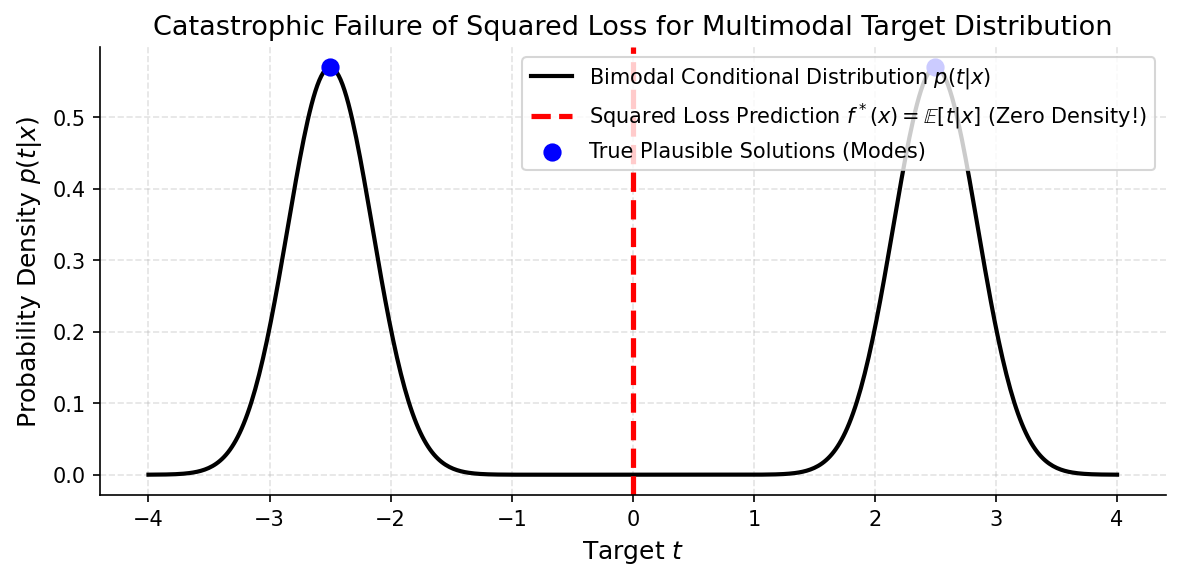

確認完了: 多峰性分布において、二乗損失の最適解 E[t|x] が解の谷間 (密度ほぼゼロ) に陥る現象を実証しました。


In [6]:
# 多峰性分布における二乗損失 (平均値) の失敗シミュレーション
# 2つの峰: t = -2.5 (モード1) と t = +2.5 (モード2)
mu_a, mu_b = -2.5, 2.5
sig_mode = 0.35

t_grid = np.linspace(-4, 4, 500)
p_bimodal = 0.5 * stats.norm.pdf(t_grid, mu_a, sig_mode) + 0.5 * stats.norm.pdf(t_grid, mu_b, sig_mode)

cond_mean_val = 0.5 * mu_a + 0.5 * mu_b # 0.0
density_at_mean = float(0.5 * stats.norm.pdf(cond_mean_val, mu_a, sig_mode) + 0.5 * stats.norm.pdf(cond_mean_val, mu_b, sig_mode))
density_at_peak = float(0.5 * stats.norm.pdf(mu_a, mu_a, sig_mode) + 0.5 * stats.norm.pdf(mu_a, mu_b, sig_mode))

print(f"条件付き平均値 E[t|x] = {cond_mean_val:.2f}")
print(f"ピークでの確率密度    = {density_at_peak:.4f}")
print(f"平均値での確率密度    = {density_at_mean:.4e}")

assert density_at_mean < 1e-10
assert np.isclose(cond_mean_val, 0.0)

plt.figure(figsize=(8, 4), dpi=150)
plt.plot(t_grid, p_bimodal, 'k-', lw=2, label='Bimodal Conditional Distribution $p(t|x)$')
plt.axvline(cond_mean_val, color='red', linestyle='--', lw=2.5, label='Squared Loss Prediction $f^*(x) = \mathbb{E}[t|x]$ (Zero Density!)')
plt.scatter([mu_a, mu_b], [density_at_peak, density_at_peak], color='blue', s=60, zorder=5, label='True Plausible Solutions (Modes)')
plt.title("Catastrophic Failure of Squared Loss for Multimodal Target Distribution")
plt.xlabel("Target $t$")
plt.ylabel("Probability Density $p(t|x)$")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print("確認完了: 多峰性分布において、二乗損失の最適解 E[t|x] が解の谷間 (密度ほぼゼロ) に陥る現象を実証しました。")

---
## まとめと次節への展望

本ノートブックでは、Bishop & Bishop (2024) Chapter 4 の **Section 4.2 Decision Theory** を厳密に数理展開・実装検証しました：

1. **推論と決定の分離**: 条件付き分布 $p(t|\mathbf{x})$ の学習（推論）と、損失関数に応じた最適予測値 $f(\mathbf{x})$ の導出（決定）。
2. **二乗損失と最適回帰関数**: 変分法により、二乗損失の最小化が条件付き平均 $f^\star(\mathbf{x}) = \mathbb{E}[t|\mathbf{x}]$ に導かれることを証明 (**Figure 4.5**)。
3. **直交分解**: 期待二乗損失が「モデル決定誤差」と「不可避固有ノイズ」に厳密に2分されることを数理・数値的に証明。
4. **ミンコフスキー損失**: 頑健性パラメータ $q$ の選択による平均 ($q=2$)、中央値 ($q=1$)、最頻値 ($q \to 0$) の使い分け (**Figure 4.6**)。
5. **多峰性分布の課題**: 逆問題などにおいて単一の条件付き平均が出力解として破綻する問題点を検証（後の第6章 6.5節「混合密度ネットワーク」への重要な布石）。

### 次節予告
続く **Section 4.3: バイアス–バリアンス分解 (The Bias–Variance Trade-off)** では、有限データセットのもとでモデルの複雑度（正則化パラメータ $\lambda$ や基底関数の数）がモデル予測の「偏り (Bias)」と「分散 (Variance)」に及ぼすトレードオフを詳しく解析します (**Figure 4.7, 4.8**)。